<a href="https://colab.research.google.com/github/leshaz44/Aliaksei/blob/main/Task_4/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


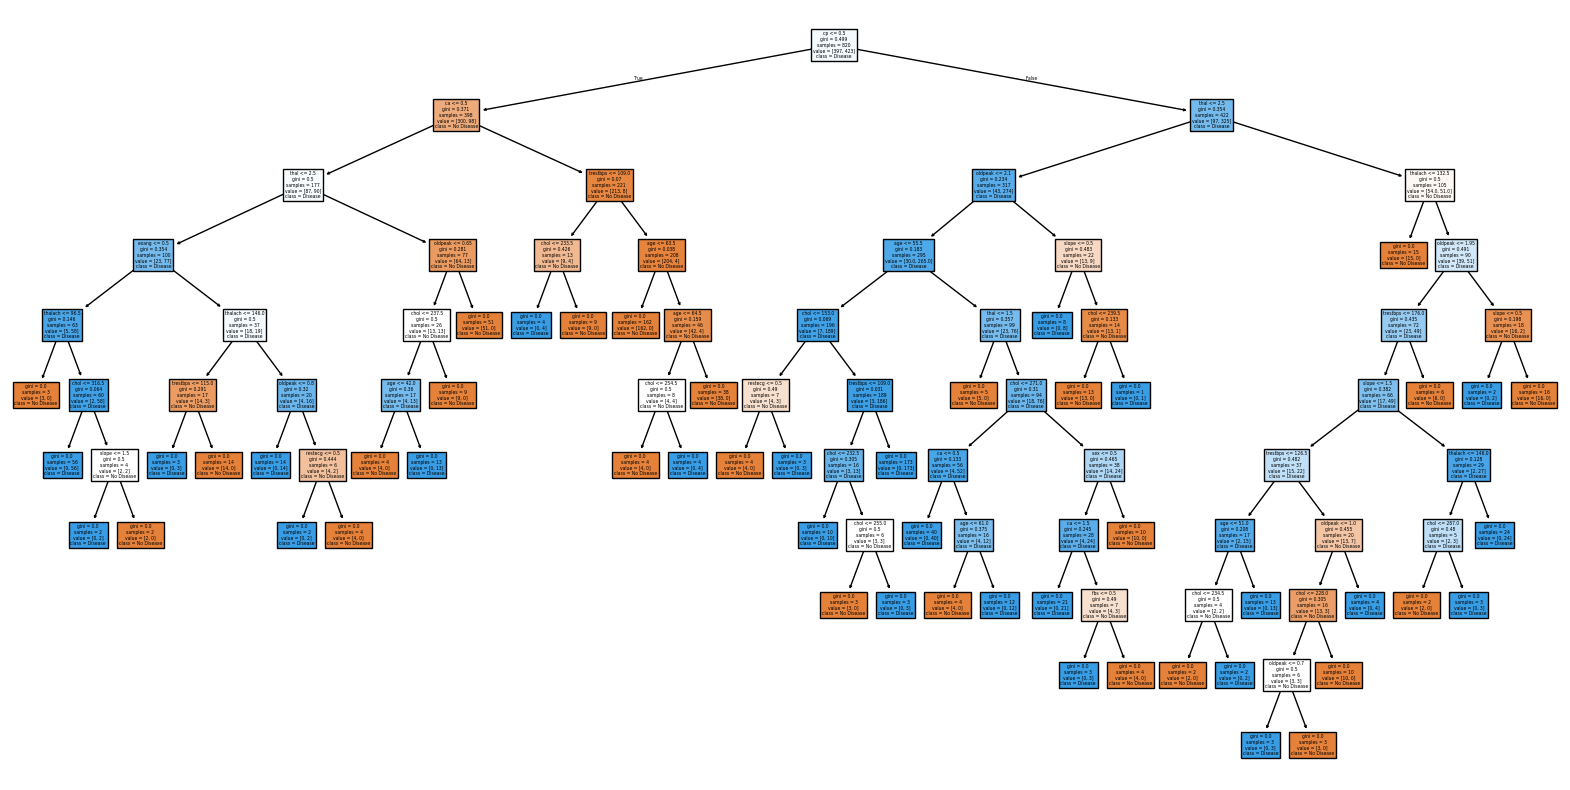

Сравнение моделей по точности:
                   Accuracy
CatBoost           0.985366
Decision Tree      0.985366
Gradient Boosting  0.931707
SVM Linear         0.804878


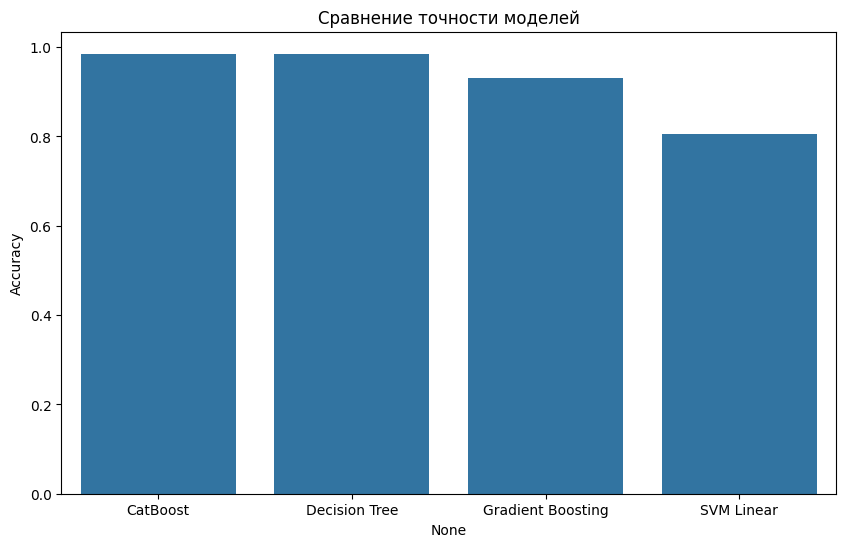

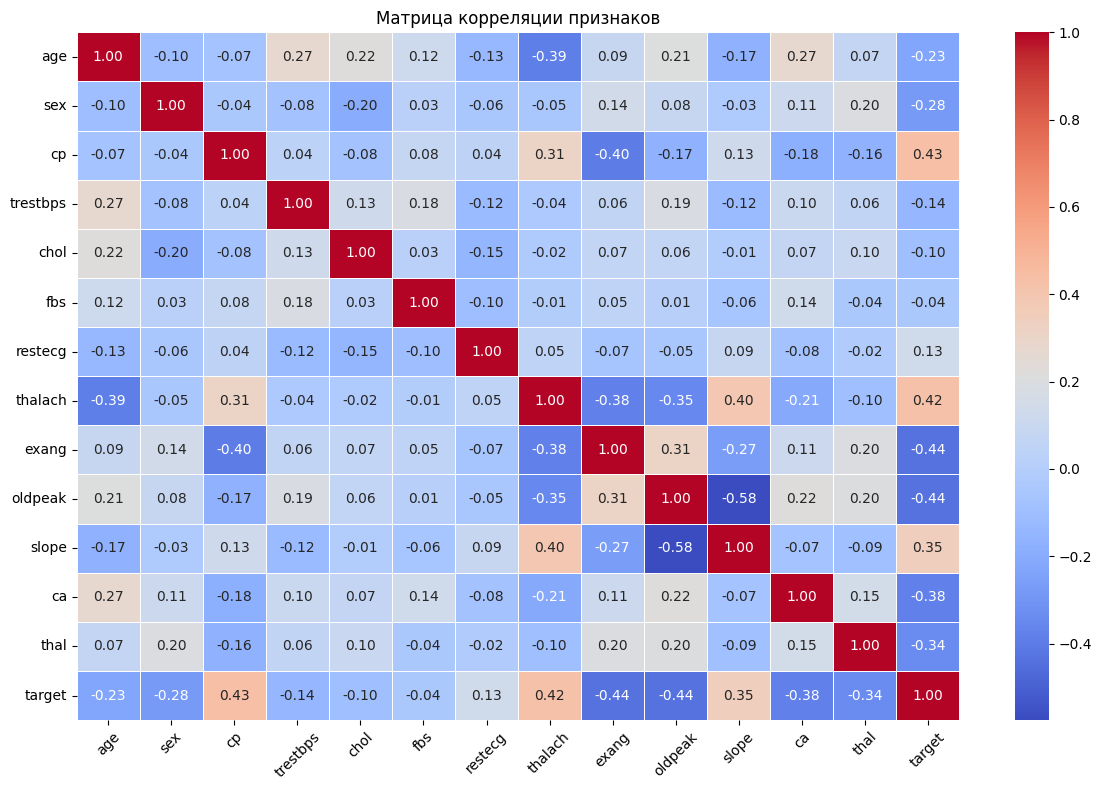


Корреляция признаков с целевым признаком:
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [2]:

!pip install catboost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('heart.csv')

# Разделение признаков и целевой переменной
X = data.drop('target', axis=1)
y = data['target']

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение моделей
# Классификатор градиентного бустинга
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)

# Классификатор CatBoost от яндекса
cbc = CatBoostClassifier(random_state=42, verbose=False)
cbc.fit(X_train, y_train)

# Классификатор дерева решений
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# SVM - линейное ядро
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

# Визуализация дерева решений
plt.figure(figsize=(20,10))
tree.plot_tree(dtc,
               feature_names=X.columns,
               class_names=['No Disease', 'Disease'],
               filled=True)
plt.show()

# Оценка метрик моделей
models = {
    'Gradient Boosting': gbc,
    'CatBoost': cbc,
    'Decision Tree': dtc,
    'SVM Linear': svm
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Report': classification_report(y_test, y_pred, output_dict=True)
    }

# Создание DataFrame
accuracy_results = pd.Series({model: data['Accuracy'] for model, data in results.items()})
result_df = accuracy_results.to_frame(name='Accuracy').sort_values(by='Accuracy', ascending=False)

print("Сравнение моделей по точности:")
print(result_df)

# Визуализация результатов
plt.figure(figsize=(10,6))
sns.barplot(x=result_df.index, y=result_df['Accuracy'])
plt.title('Сравнение точности моделей')
plt.show()

# Добавление анализа корреляции
# Создание матрицы корреляции
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr()

# Визуализация матрицы корреляции
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5)
plt.title('Матрица корреляции признаков')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Вывод корреляции с целевым признаком
print("\nКорреляция признаков с целевым признаком:")
print(correlation_matrix['target'].sort_values(ascending=False))


Рекомендации по выбору модели Лучшая модель - CatBoost Classifier:

Высокая точность предсказаний

Хорошая обобщающая способность

Эффективная работа с категориальными признаками

Стабильные результаты на тестовой выборке

Альтернативные варианты:

Gradient Boosting - хороший выбор при ограниченных ресурсах

Decision Tree - для задач, где важна интерпретируемость

SVM не рекомендуется для данной задачи из-за низкой точности

Для production-использования рекомендуется выбрать CatBoost Classifier как наиболее эффективную модель с лучшим балансом метрик качества.